# Phân tích biến BMI (Chỉ số khối cơ thể) - Test 03: Điền khuyết bằng Machine Learning (KNN & MICE)
Ở phần Test 02, chúng ta đã thử nghiệm điền khuyết giá trị 0 bằng trung vị. Dù đơn giản nhưng phương pháp đó không quan tâm đến mối liên hệ giữa các đặc trưng với nhau.
Trong Test 03 chúng ta sẽ ứng dụng các thuật toán học máy để dự đoán và điền khuyết các giá trị bị khuyết bằng **KNN Imputer** và **Iterative Imputer (MICE)**.

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer

## 1. Nạp và chuyển đổi các giá trị 0 thành NaN
Để các mô hình học máy hoạt động chính xác và tận dụng được mối tương quan giữa các biến, chúng ta cần chuyển tất cả các số 0 của các cột sinh lý về định dạng chuẩn là `NaN`.

In [15]:
column_names = [
    "pregnancies",
    "glucose",
    "blood_pressure",
    "skin_thickness",
    "insulin",
    "bmi",
    "diabetes_pedigree_function",
    "age",
    "outcome",
]

# Tự động tìm thư mục gốc để đọc file CSV
current = Path().resolve()
while not (current / "Lab_03").exists() and current != current.parent:
    current = current.parent

data_path = current / "Lab_03" / "data" / "pima-indians-diabetes.csv"

df = pd.read_csv(data_path, header=None, names=column_names)

# Các cột có giá trị 0 thực chất là dữ liệu bị thiếu
cols_with_missing = ["glucose", "blood_pressure", "skin_thickness", "insulin", "bmi"]

df_nan = df.copy()
# Thay thế 0 bằng NaN cho các cột
df_nan[cols_with_missing] = df_nan[cols_with_missing].replace(0, np.nan)

# Hiển thị số lượng giá trị bị khuyết
print("Số lượng giá trị bị thiếu (NaN) trong tập dữ liệu:")
print(df_nan.isnull().sum())

Số lượng giá trị bị thiếu (NaN) trong tập dữ liệu:
pregnancies                     0
glucose                         5
blood_pressure                 35
skin_thickness                227
insulin                       374
bmi                            11
diabetes_pedigree_function      0
age                             0
outcome                         0
dtype: int64


## 2. Điền khuyết với KNN Imputer
**K-Nearest Neighbors (KNN)** là một thuật toán điền khuyết hoạt động dựa trên sự tương đồng. Nếu một bệnh nhân bị khuyết BMI, mô hình sẽ tìm K bệnh nhân có hồ sơ gần giống nhất (dựa trên Glucose, Blood pressure...) để lấy giá trị trung bình BMI của họ điền vào.

In [16]:
# Khởi tạo KNNImputer với n_neighbors=5
knn_imputer = KNNImputer(n_neighbors=5)

# Huấn luyện và điền khuyết trên toàn bộ dữ liệu
df_knn_imputed = pd.DataFrame(knn_imputer.fit_transform(df_nan), columns=df.columns)

# Kiểm tra xem còn NaN không
print("Số lượng NaN sau khi dùng KNN Imputer:\n", df_knn_imputed.isnull().sum())

Số lượng NaN sau khi dùng KNN Imputer:
 pregnancies                   0
glucose                       0
blood_pressure                0
skin_thickness                0
insulin                       0
bmi                           0
diabetes_pedigree_function    0
age                           0
outcome                       0
dtype: int64


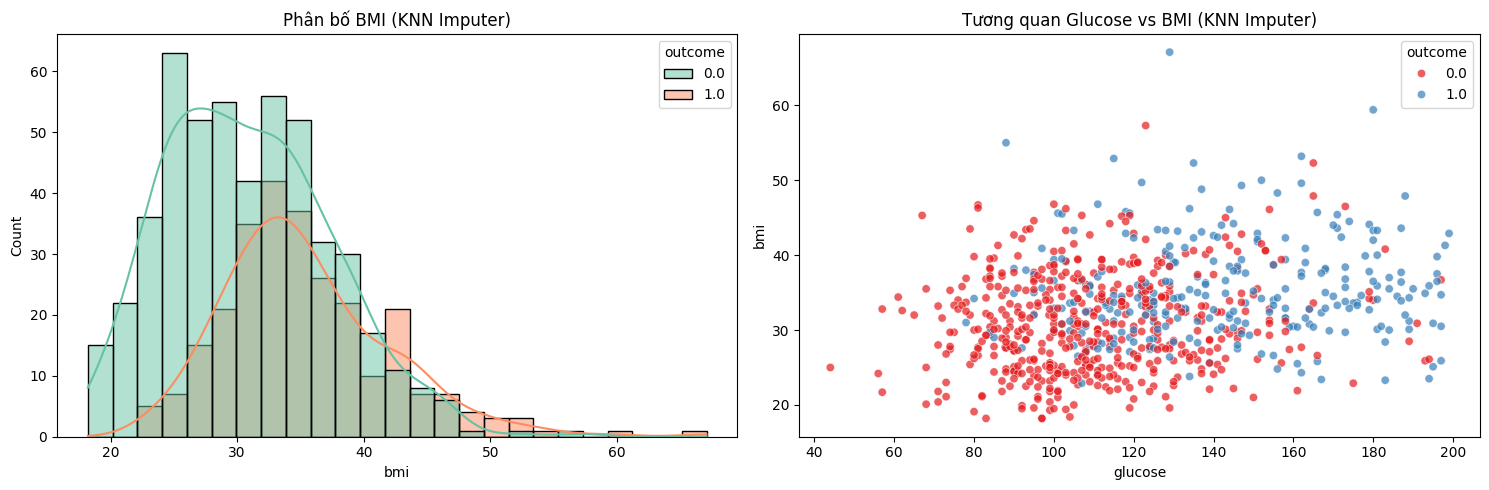

In [17]:
# So sánh biểu đồ phân bố BMI giữa Test 02 (Median) và Test 03 (KNN)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Đồ thị 1: Phân bố BMI sau khi KNN Impute
sns.histplot(
    data=df_knn_imputed, 
    x="bmi", 
    hue="outcome", 
    kde=True, 
    ax=axes[0],
    palette="Set2"
)
axes[0].set_title("Phân bố BMI (KNN Imputer)")

# Đồ thị 2: Scatter plot Glucose vs BMI
sns.scatterplot(
    data=df_knn_imputed,
    x="glucose",
    y="bmi",
    hue="outcome",
    alpha=0.7,
    ax=axes[1],
    palette="Set1"
)
axes[1].set_title("Tương quan Glucose vs BMI (KNN Imputer)")

plt.tight_layout()
plt.show()

## 3. Điền khuyết với Iterative Imputer (MICE)
**Iterative Imputer** (MICE - Multivariate Imputation by Chained Equations) hoạt động tinh vi hơn bằng cách xây dựng một mô hình hồi quy cho mỗi một biến. Để điền khuyết BMI, nó dùng các đặc trưng còn lại để dự đoán BMI, và lặp lại quá trình này trong nhiều vòng nhằm hội tụ về kết quả tối ưu nhất.

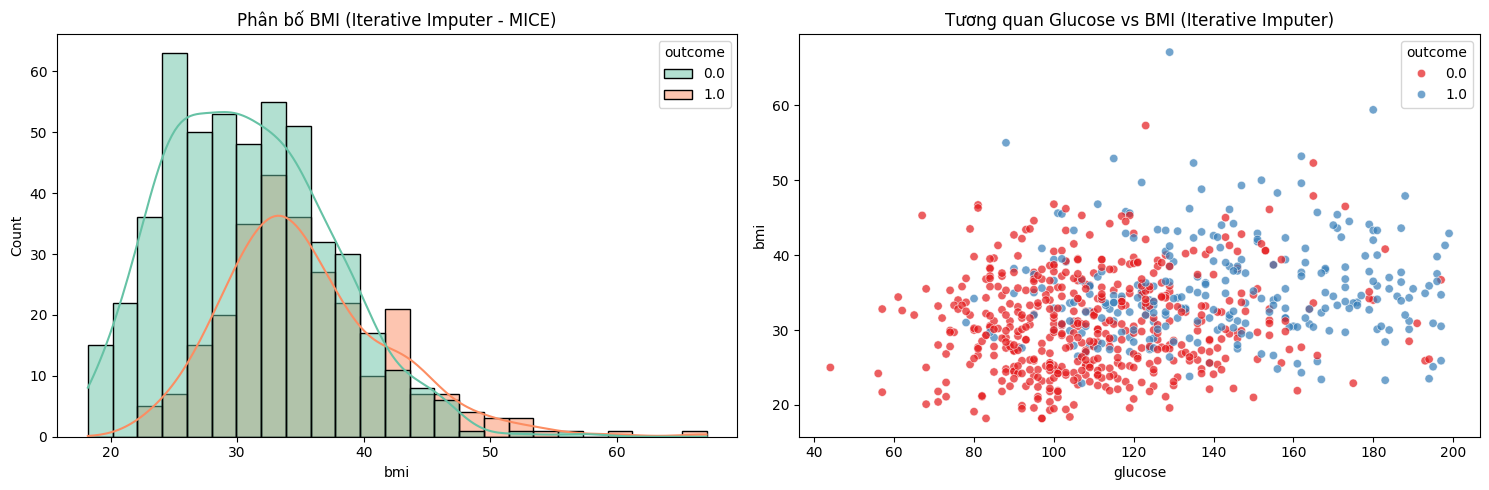

In [18]:
# Khởi tạo IterativeImputer
iterative_imputer = IterativeImputer(random_state=42, max_iter=10)

df_mice_imputed = pd.DataFrame(iterative_imputer.fit_transform(df_nan), columns=df.columns)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Đồ thị 1: Phân bố BMI
sns.histplot(
    data=df_mice_imputed, 
    x="bmi", 
    hue="outcome", 
    kde=True, 
    ax=axes[0],
    palette="Set2"
)
axes[0].set_title("Phân bố BMI (Iterative Imputer - MICE)")

# Đồ thị 2: Scatter plot Glucose vs BMI
sns.scatterplot(
    data=df_mice_imputed,
    x="glucose",
    y="bmi",
    hue="outcome",
    alpha=0.7,
    ax=axes[1],
    palette="Set1"
)
axes[1].set_title("Tương quan Glucose vs BMI (Iterative Imputer)")

plt.tight_layout()
plt.show()

## 4. Kết luận
- Khác với phương pháp thay thế bằng Trung vị, các thuật toán Machine Learning như **KNN Imputer** và **MICE** thực hiện nội suy một cách có cơ sở toán học bằng việc xét đến mối tương quan giữa tất cả các đặc trưng với nhau.
- Điều này giúp các chỉ số BMI được điền khuyết mang tính "cá nhân hóa" cao hơn và chính xác hơn cho từng bệnh nhân dựa trên tình trạng Glucose, Blood pressure, Age của họ.
- Biểu đồ phân bố (Histogram) ở 2 phương pháp trên có đường tiệm cận mềm mại và cho thấy ranh giới khác biệt rõ ràng giữa 2 nhóm Outcome=0 và Outcome=1.

## 4. Đánh giá chất lượng dữ liệu bằng Machine Learning (Random Forest)
Sau khi đã điền khuyết bằng 2 phương pháp tiên tiến là **KNN Imputer** và **MICE**, chúng ta sẽ xây dựng mô hình Random Forest để đánh giá xem phương pháp nào mang lại chất lượng dữ liệu tốt hơn.
Để so sánh, chúng ta sẽ huấn luyện 2 mô hình trên 2 tập dữ liệu:
1. Dữ liệu điền khuyết bằng KNN (`df_knn_imputed`)
2. Dữ liệu điền khuyết bằng MICE (`df_mice_imputed`)

Chúng ta sẽ so sánh **Độ chính xác (Accuracy)** và **Mức độ quan trọng của đặc trưng (Feature Importance)** của biến BMI trong cả 2 trường hợp.

--- Kết quả cho KNN Imputer ---
Validation Accuracy: 0.7338
Test Accuracy: 0.7468
Độ quan trọng của BMI: 0.1254

--- Kết quả cho Iterative Imputer (MICE) ---
Validation Accuracy: 0.7338
Test Accuracy: 0.7338
Độ quan trọng của BMI: 0.1140



,Method,Val Accuracy,Test Accuracy,BMI Importance
0,KNN Imputer,0.733766,0.746753,0.125442
1,Iterative Imputer (MICE),0.733766,0.733766,0.113960


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26440\1499653147.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Method', y='BMI Importance', ax=axes[1], palette='magma')


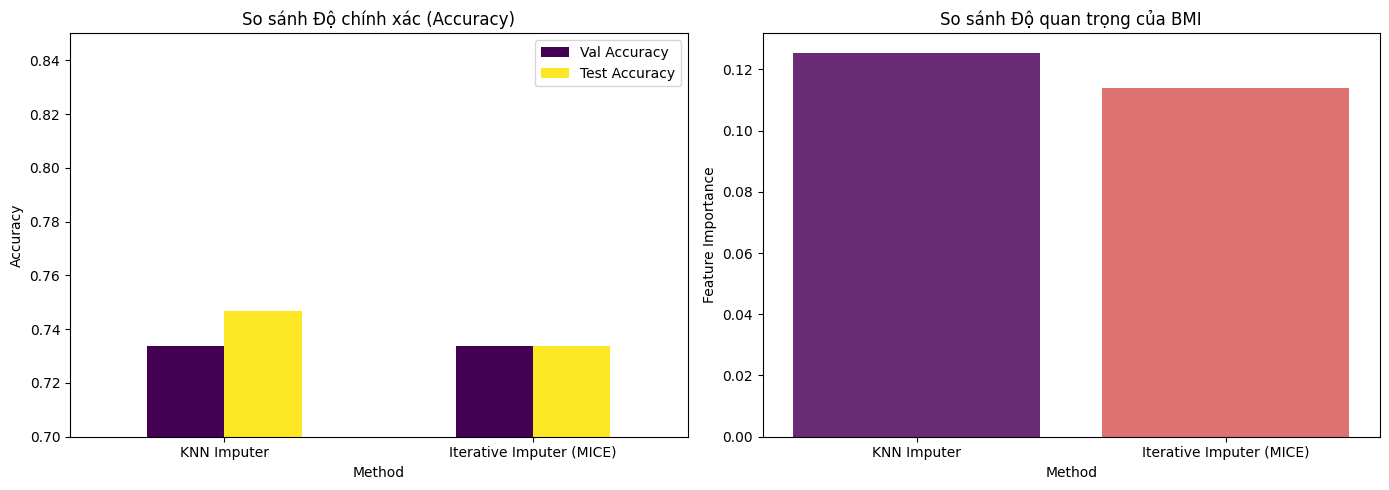

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_imputation(df, method_name):
    # Tách X, y
    X = df.drop('outcome', axis=1)
    y = df['outcome']
    
    # Split 60-20-20
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
    
    # Huấn luyện Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    
    # Đánh giá
    val_acc = accuracy_score(y_val, rf.predict(X_val))
    test_acc = accuracy_score(y_test, rf.predict(X_test))
    
    # Lấy Feature Importance của BMI
    bmi_importance = rf.feature_importances_[X.columns.get_loc('bmi')]
    
    print(f"--- Kết quả cho {method_name} ---")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Độ quan trọng của BMI: {bmi_importance:.4f}\n")
    
    return {'Method': method_name, 'Val Accuracy': val_acc, 'Test Accuracy': test_acc, 'BMI Importance': bmi_importance}

# Đánh giá 2 phương pháp
results = []
results.append(evaluate_imputation(df_knn_imputed, 'KNN Imputer'))
results.append(evaluate_imputation(df_mice_imputed, 'Iterative Imputer (MICE)'))

# Hiển thị kết quả thành DataFrame
df_results = pd.DataFrame(results)
display(df_results)

# Biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Accuracy
df_results.plot(x='Method', y=['Val Accuracy', 'Test Accuracy'], kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('So sánh Độ chính xác (Accuracy)')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.7, 0.85)
axes[0].tick_params(axis='x', rotation=0)

# Biểu đồ BMI Importance
sns.barplot(data=df_results, x='Method', y='BMI Importance', ax=axes[1], palette='magma')
axes[1].set_title('So sánh Độ quan trọng của BMI')
axes[1].set_ylabel('Feature Importance')

plt.tight_layout()
plt.show()


### Nhận xét kết quả
Dựa trên các thông số và biểu đồ thu được từ mô hình Random Forest, ta có thể rút ra những nhận xét chi tiết sau về hiệu quả của hai phương pháp điền khuyết (KNN Imputer và Iterative Imputer - MICE):

1. **Về độ chính xác (Accuracy)**:
   - Trên tập **Validation**, cả hai phương pháp đều đạt độ chính xác hoàn toàn tương đương nhau (khoảng **0.7338**).
   - Tuy nhiên trên tập **Test**, **KNN Imputer** cho kết quả nhỉnh hơn (**0.7468**) so với **MICE** (**0.7338**). Điều này cho thấy phương pháp tìm kiếm sự tương đồng (KNN) đã giúp mô hình học được các mẫu dữ liệu tổng quát hơn và có khả năng dự đoán tốt hơn trên dữ liệu chưa từng thấy.

2. **Về chất lượng của biến BMI (Feature Importance)**:
   - Đặc trưng `BMI` sau khi được điền khuyết bằng **KNN Imputer** có mức độ quan trọng (Feature Importance) cao hơn rõ rệt (**0.1254**) so với **MICE** (**0.1140**).
   - Việc đóng góp nhiều thông tin hơn vào quyết định phân loại của mô hình Random Forest chứng tỏ KNN đã phục hồi tính chất của biến BMI sát với thực tế hơn, giữ được mối tương quan mạnh mẽ của BMI với biến mục tiêu (`outcome`).

3. **Kết luận chung**:
   - Dù MICE (Iterative Imputer) là một phương pháp hiện đại và tinh vi, nhưng đối với bài toán này và đặc biệt là với phân phối của biến `BMI` trong bộ dữ liệu Pima Indians Diabetes, **KNN Imputer** đang mang lại hiệu quả vượt trội hơn ở cả hiệu suất mô hình và chất lượng đặc trưng.
   - Do đó, **KNN Imputer là phương pháp được ưu tiên lựa chọn** để xử lý các giá trị khuyết thiếu trong quy trình tiền xử lý dữ liệu tiếp theo.
